In [1]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit,  ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import qiskit_aer.noise as noise
from qiskit import QuantumCircuit, transpile
from qiskit import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.transpiler.passes import ALAPScheduleAnalysis
from qiskit.transpiler import PassManager
import csv
from qiskit.visualization import plot_histogram, plot_distribution


In [2]:
## Save your IBM Quantum account and set it as your default account.
your_api_key = "9hJ2tQCPO5ZQfbTqHZJ9MVvWw_VIcdVf-PSrSRU2A9Sx"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e68d80097b441d1a02d32bf585bedac:6ef82fed-0a87-4949-a472-bfa604ffc372::"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="Surface_Code",
    overwrite=True
)
service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = AerSimulator()

In [19]:
# backend_properties = backend.properties(backend)


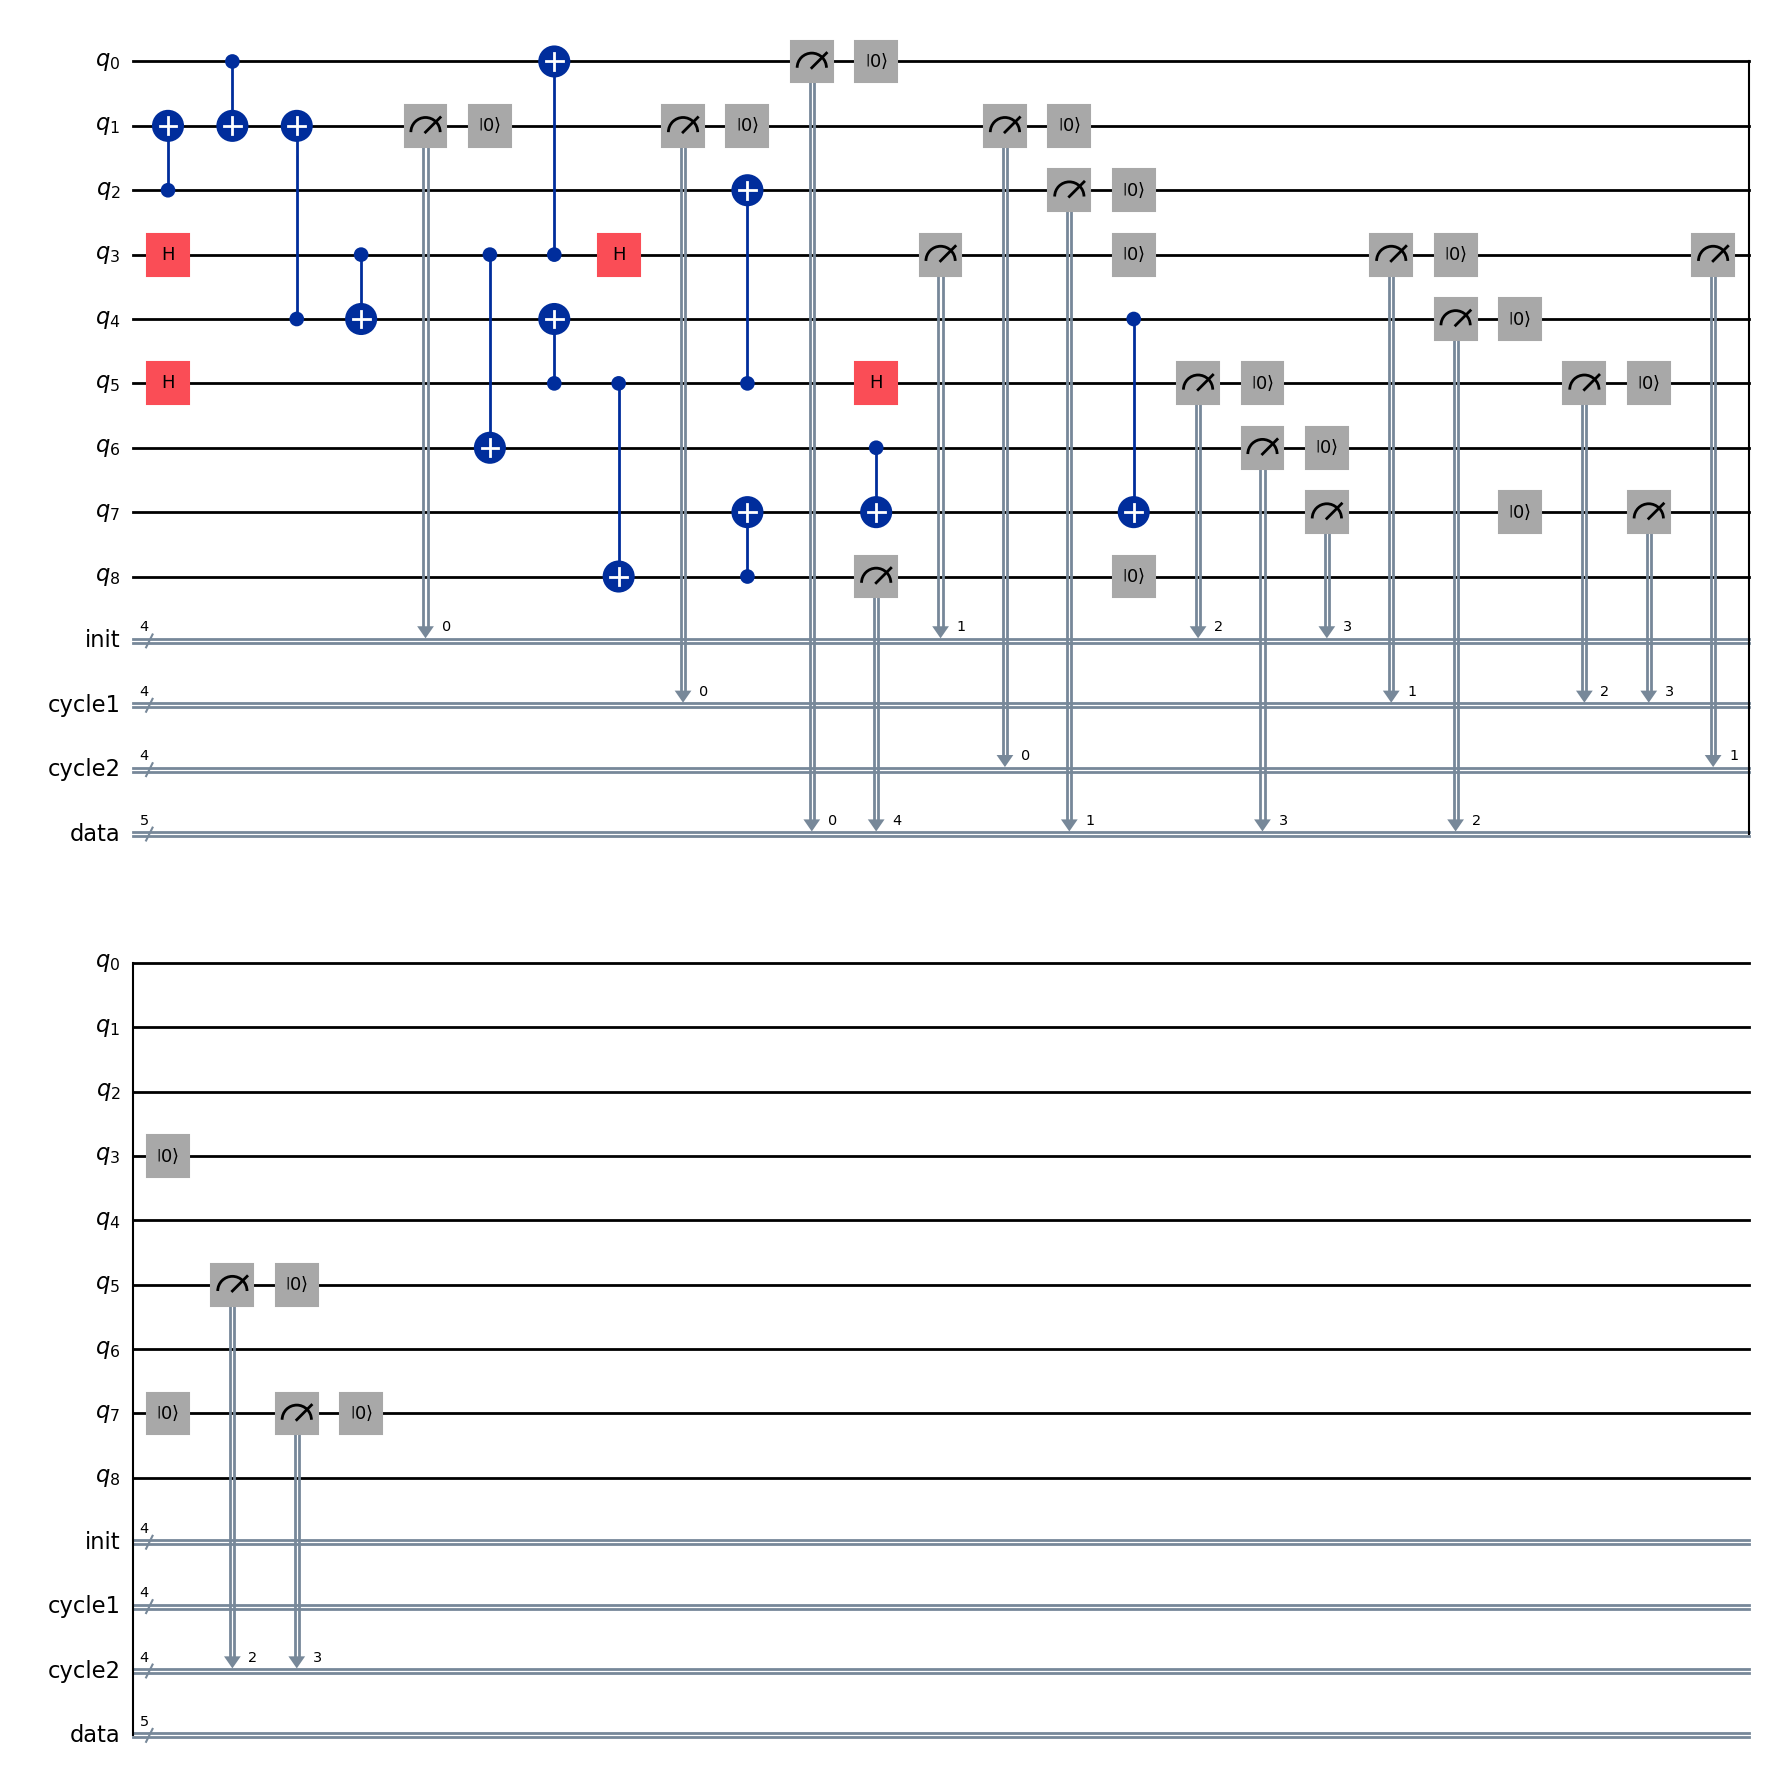

In [2]:
# finalQc = split_surface(backend)
from GridCreator import GridCreator

finalQc = GridCreator.createGrid(1, 1)
# finalQc.measure_all()

display (finalQc.draw('mpl'))

In [8]:
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error, pauli_error

# Example error probabilities
p_reset = 0.03
p_meas = 0.1
p_gate1 = 0.05
 
# QuantumError objects
error_reset = pauli_error([("X", p_reset), ("I", 1 - p_reset)])
error_meas = pauli_error([("X", p_meas), ("I", 1 - p_meas)])
error_gate1 = pauli_error([("X", p_gate1), ("I", 1 - p_gate1)])
error_gate2 = error_gate1.tensor(error_gate1)
 
# Add errors to noise model
noise_bit_flip = NoiseModel()
noise_bit_flip.add_all_qubit_quantum_error(error_reset, "reset")
noise_bit_flip.add_all_qubit_quantum_error(error_meas, "measure")
noise_bit_flip.add_all_qubit_quantum_error(error_gate1, ["u1", "u2", "u3"])
noise_bit_flip.add_all_qubit_quantum_error(error_gate2, ["cx"])
 
print(noise_bit_flip)


NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx', 'u1', 'u2', 'u3']
  Instructions with noise: ['u1', 'u3', 'measure', 'reset', 'u2', 'cx']
  All-qubits errors: ['reset', 'measure', 'u1', 'u2', 'u3', 'cx']


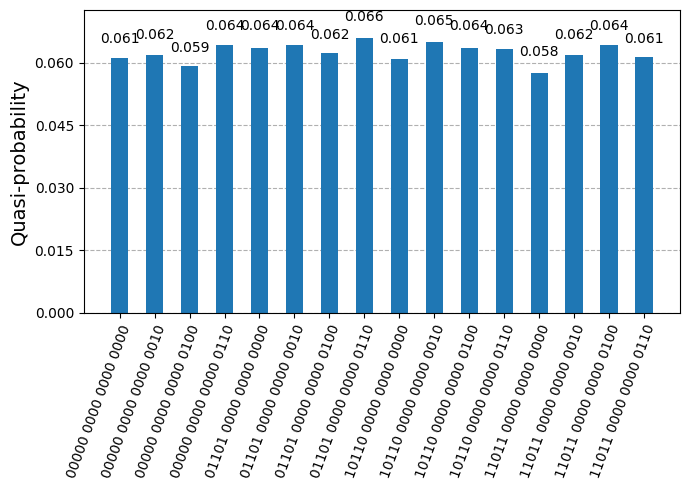

In [3]:

backend = AerSimulator()

transpiled_circ = transpile(finalQc, backend)
# transpiled_circ.save_statevector()

job = backend.run(transpiled_circ, shots=10000)
result = job.result()

counts = result.get_counts()
plot_distribution(counts)



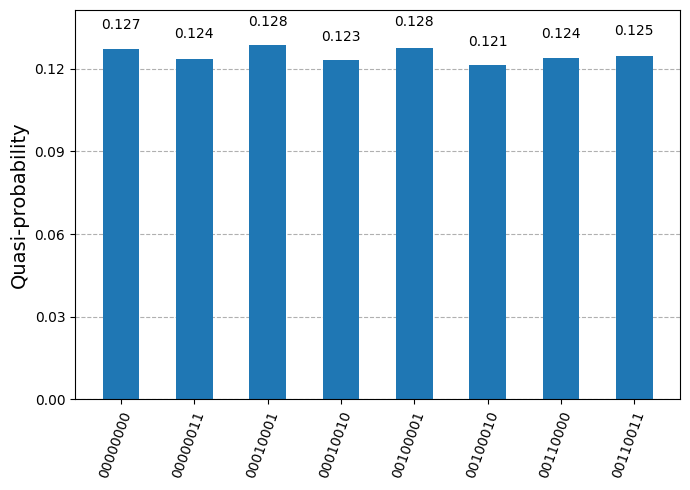

In [4]:
init_counts = {}

# print(counts)

for key, val in counts.items():
    reversed_key = key[::-1]
    init = reversed_key[0:8]
    init_counts[init] = init_counts.get(init, 0) + val

plot_distribution(init_counts)   

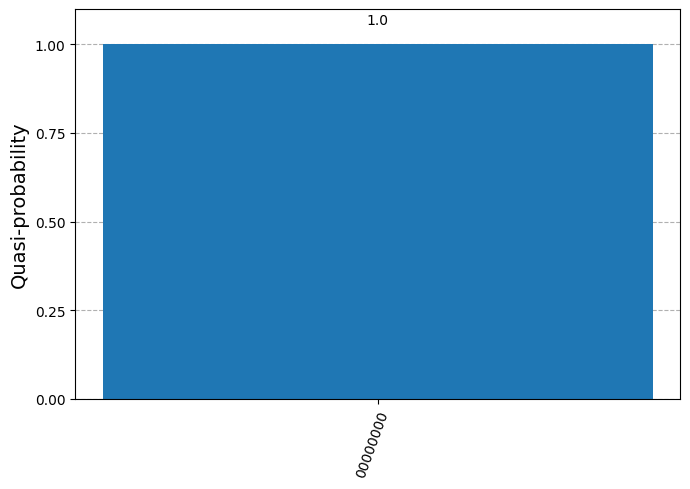

In [5]:
second_round_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    second_round = reversed_key[9:17] 
    second_round_counts[second_round] = second_round_counts.get(second_round, 0) + val

plot_distribution(second_round_counts)

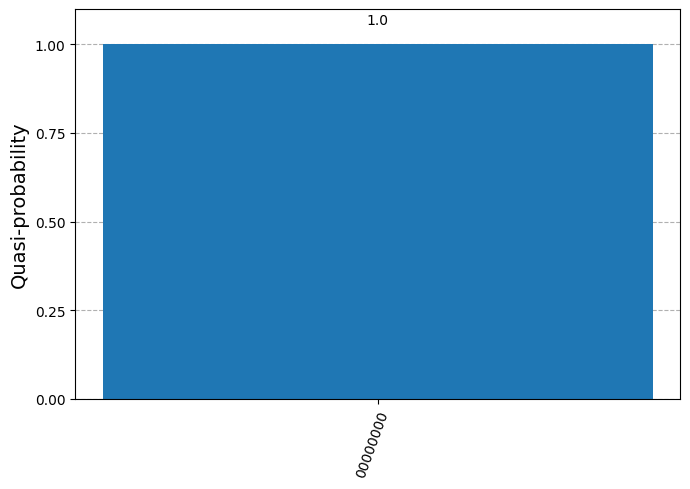

In [6]:
third_round_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    third_round = reversed_key[18:26] 
    third_round_counts[third_round] = third_round_counts.get(third_round, 0) + val

plot_distribution(third_round_counts)

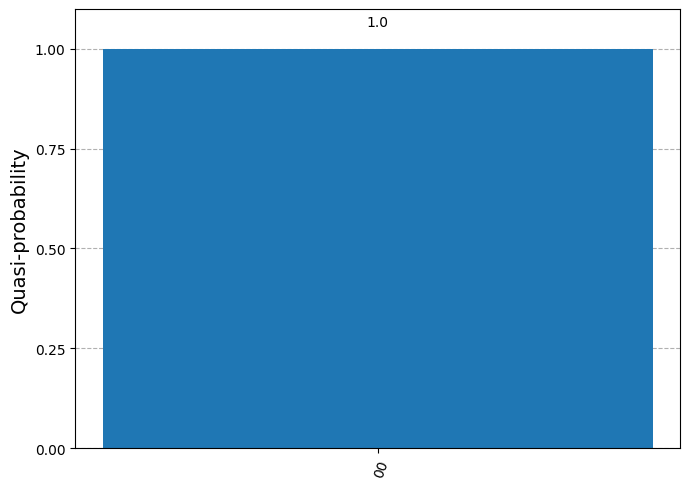

In [7]:
data_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    data = key[27:29]  
    data_counts[data] = data_counts.get(data, 0) + val

plot_distribution(data_counts)

In [4]:
state_vector = result.get_statevector()

# data, dims = state_vector


for rez in state_vector:
    print(rez)


/tmp/ipykernel_15740/2233329903.py:6: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for rez in state_vector:


0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0j
0

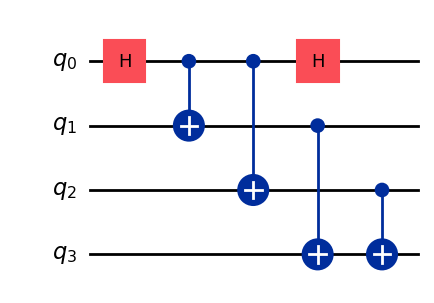

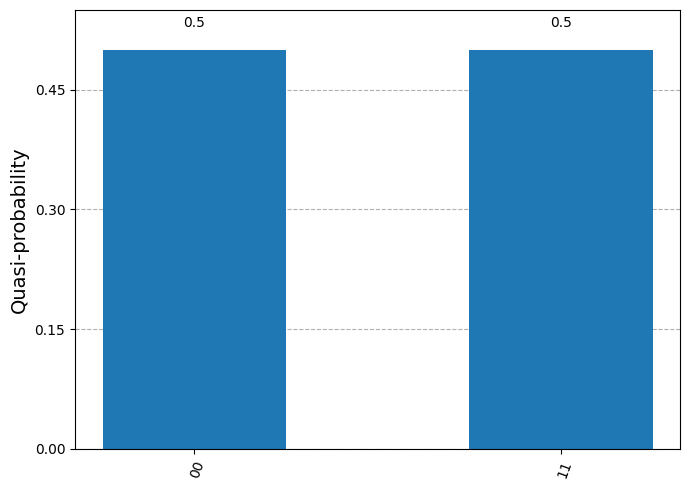

In [42]:
finalQc = QuantumCircuit(4)

finalQc.h(0)

# finalQc.x(2)
# finalQc.x(1)
# finalQc.h(1)
# finalQc.h(2)

finalQc.cx(0, 1)
finalQc.cx(0, 2)
finalQc.cx(1, 3)
finalQc.cx(2, 3)

finalQc.h(0)


# finalQc.h(2)
# finalQc.h(1)

# finalQc.measure_all()

display (finalQc.draw('mpl'))

backend = AerSimulator()

transpiled_circ = transpile(finalQc, backend)
transpiled_circ.save_statevector()

job = backend.run(transpiled_circ, shots=10000)
result = job.result()

counts = result.get_counts()
data_counts = {}

for key, val in counts.items():
    reversed_key = key[::-1]
    data = key[1:3]  
    data_counts[data] = data_counts.get(data, 0) + val

plot_distribution(data_counts)
# print(result.get_statevector())